<a href="https://colab.research.google.com/github/Ramya-S30/WildLife_Camera_Trap/blob/main/Wildlife_Camera_Trap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Load the Dataset

In [5]:
df = pd.read_csv("Q08_wildlife_camera_trap.csv")
print(df.head())
print(df.shape)
print(df.info())

  observation_id  species     sighting_time location trigger_type
0         WT0001  Peacock  2026-04-16 04:16   Zone_B       Motion
1         WT0002  Peacock  2026-03-01 20:49   Zone_B       Motion
2         WT0003  Leopard  2026-05-16 11:35   Zone_B       Motion
3         WT0004     Boar  2026-03-13 21:09   Zone_B        Blank
4         WT0005  Peacock  2026-01-26 10:16   Zone_D       Motion
(123, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   observation_id  123 non-null    object
 1   species         123 non-null    object
 2   sighting_time   123 non-null    object
 3   location        121 non-null    object
 4   trigger_type    121 non-null    object
dtypes: object(5)
memory usage: 4.9+ KB
None


3. Check Missing Values

In [6]:
print(df.isnull().sum())

observation_id    0
species           0
sighting_time     0
location          2
trigger_type      2
dtype: int64


4. Remove Missing and Duplicate Records

In [7]:
df = df.dropna()
df = df.drop_duplicates()
print("Records after cleaning:", len(df))

Records after cleaning: 117


5. Remove Blank Trigger Records

In [8]:
df = df[df["trigger_type"] != "Blank"]
print("Records after removing blank triggers:", len(df))

Records after removing blank triggers: 86


6. Convert Sighting Time

In [9]:
df["sighting_time"] = pd.to_datetime(df["sighting_time"])
print(df["sighting_time"].head())

0   2026-04-16 04:16:00
1   2026-03-01 20:49:00
2   2026-05-16 11:35:00
4   2026-01-26 10:16:00
5   2026-05-31 03:04:00
Name: sighting_time, dtype: datetime64[ns]


7. Create Hour Feature

In [10]:
df["hour"] = df["sighting_time"].dt.hour
print(df[["sighting_time", "hour"]].head())

        sighting_time  hour
0 2026-04-16 04:16:00     4
1 2026-03-01 20:49:00    20
2 2026-05-16 11:35:00    11
4 2026-01-26 10:16:00    10
5 2026-05-31 03:04:00     3


8. Create Nocturnal Activity Indicator

In [11]:
def activity_period(hour):
    if hour >= 18 or hour < 6:
        return "Nocturnal"
    else:
        return "Diurnal"

df["activity_period"] = df["hour"].apply(activity_period)

print(df[["sighting_time", "activity_period"]].head())

        sighting_time activity_period
0 2026-04-16 04:16:00       Nocturnal
1 2026-03-01 20:49:00       Nocturnal
2 2026-05-16 11:35:00         Diurnal
4 2026-01-26 10:16:00         Diurnal
5 2026-05-31 03:04:00       Nocturnal


9. Species-wise Activity

In [12]:
species_activity = df["species"].value_counts()

print("Species-wise sightings:")
print(species_activity)

Species-wise sightings:
species
Leopard     26
Elephant    21
Deer        17
Peacock     12
Boar        10
Name: count, dtype: int64


10. Location-wise Activity

In [13]:
location_activity = df["location"].value_counts()

print("Location-wise sightings:")
print(location_activity)

Location-wise sightings:
location
Zone_C    26
Zone_D    23
Zone_B    19
Zone_A    18
Name: count, dtype: int64


11. Diurnal vs Nocturnal Activity

In [14]:
period_activity = df["activity_period"].value_counts()

print("Activity period:")
print(period_activity)

Activity period:
activity_period
Nocturnal    45
Diurnal      41
Name: count, dtype: int64


12. Species vs Location

In [16]:
species_location = pd.crosstab(
    df["species"],
    df["location"]
)
print(species_location)

location  Zone_A  Zone_B  Zone_C  Zone_D
species                                 
Boar           1       3       4       2
Deer           4       1       7       5
Elephant       8       2       7       4
Leopard        3       7       8       8
Peacock        2       6       0       4


13. Species vs Activity Period

In [17]:
species_period = pd.crosstab(
    df["species"],
    df["activity_period"]
)

print(species_period)

activity_period  Diurnal  Nocturnal
species                            
Boar                   4          6
Deer                   7         10
Elephant              11         10
Leopard               14         12
Peacock                5          7


14. Hour-wise Wildlife Activity

In [18]:
hourly_activity = df["hour"].value_counts().sort_index()

print("Hourly activity:")
print(hourly_activity)

Hourly activity:
hour
0     4
1     4
2     2
3     4
4     6
5     5
6     5
7     4
9     5
10    4
11    7
12    2
13    4
14    2
15    3
16    2
17    3
18    3
19    5
20    2
21    3
22    3
23    4
Name: count, dtype: int64


15. Find Most Active Location

In [19]:
most_active_location = location_activity.idxmax()

print("Most active location:", most_active_location)

Most active location: Zone_C


16. Save Cleaned Dataset


In [20]:
df.to_csv("cleaned_wildlife_camera_trap.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# VISUALIZATION

1. Species-wise Sighting Frequency — Bar Chart

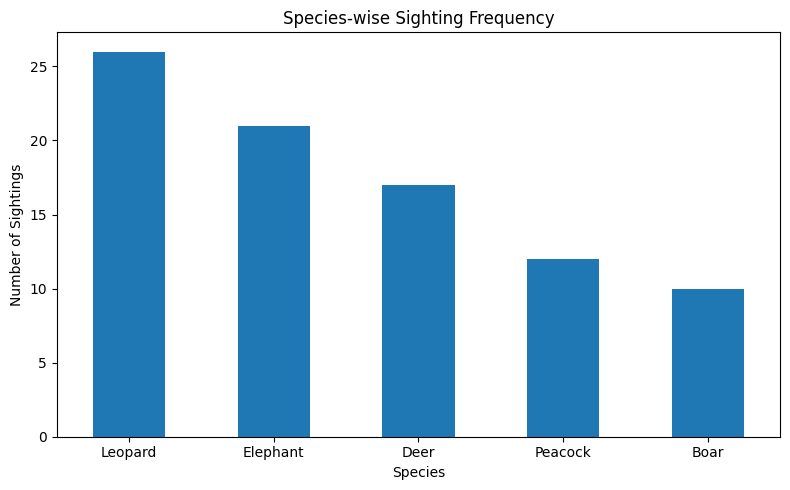

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Species-wise sightings
species_count = df["species"].value_counts()

plt.figure(figsize=(8,5))
species_count.plot(kind="bar")
plt.title("Species-wise Sighting Frequency")
plt.xlabel("Species")
plt.ylabel("Number of Sightings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

2. Location-wise Sighting Frequency — Bar Chart

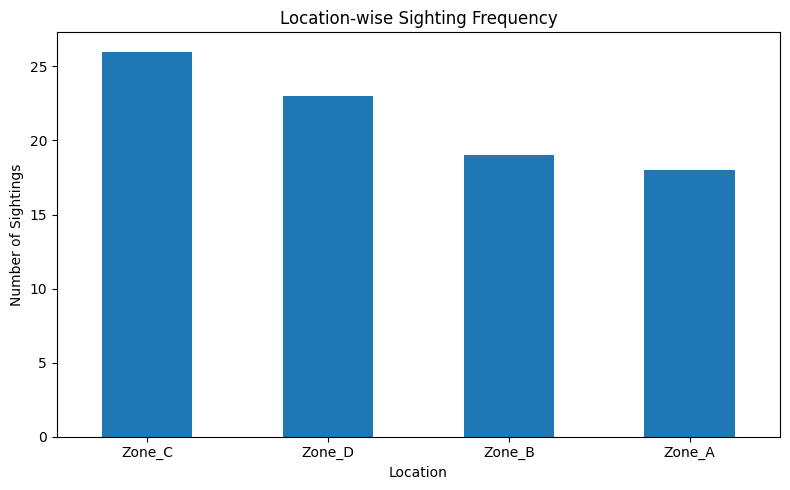

In [22]:
location_count = df["location"].value_counts()

plt.figure(figsize=(8,5))
location_count.plot(kind="bar")
plt.title("Location-wise Sighting Frequency")
plt.xlabel("Location")
plt.ylabel("Number of Sightings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

3. Diurnal vs Nocturnal Activity — Pie Chart

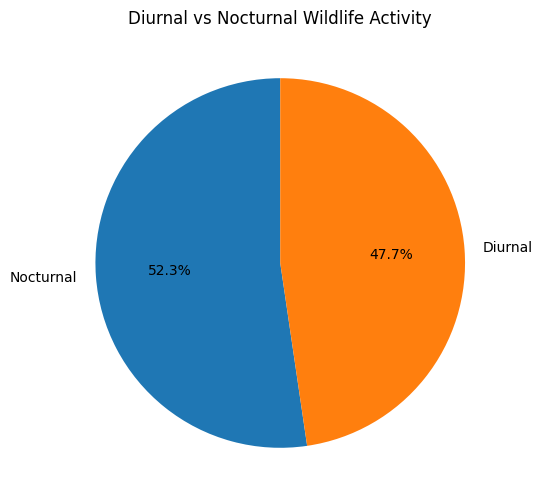

In [23]:
period_count = df["activity_period"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    period_count,
    labels=period_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Diurnal vs Nocturnal Wildlife Activity")
plt.show()

4.Species vs Location - Heatmap

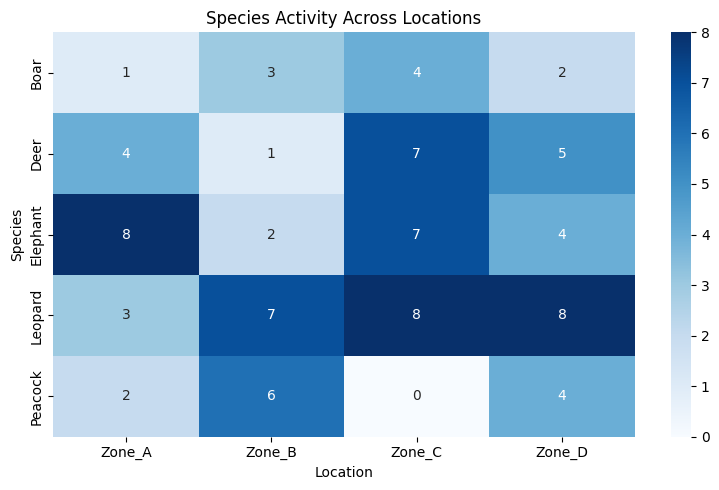

In [24]:
species_location = pd.crosstab(
    df["species"],
    df["location"]
)

plt.figure(figsize=(8,5))
sns.heatmap(
    species_location,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Species Activity Across Locations")
plt.xlabel("Location")
plt.ylabel("Species")
plt.tight_layout()
plt.show()

5. Hour-wise Wildlife Activity — Line Chart

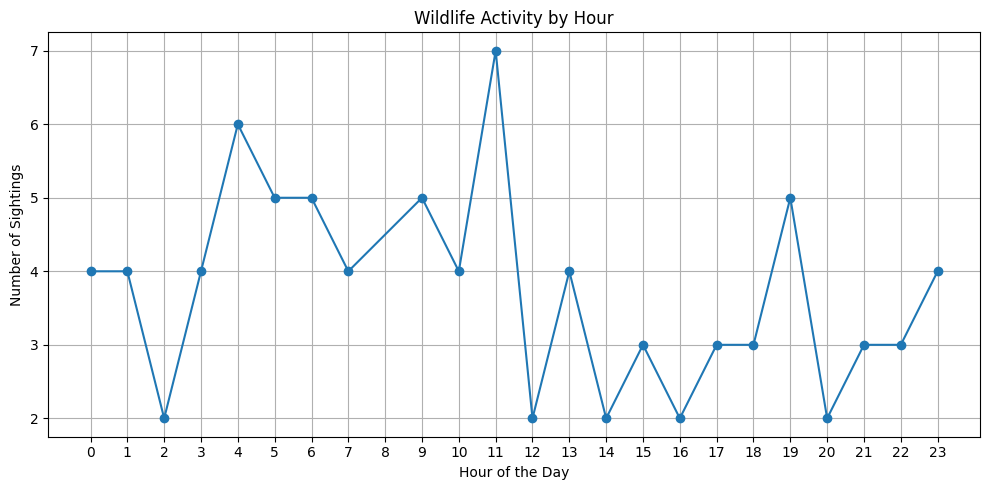

In [25]:
hourly_activity = df["hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(
    hourly_activity.index,
    hourly_activity.values,
    marker="o"
)

plt.title("Wildlife Activity by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Sightings")
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.show()

6. Additional Chart — Species vs Activity Period

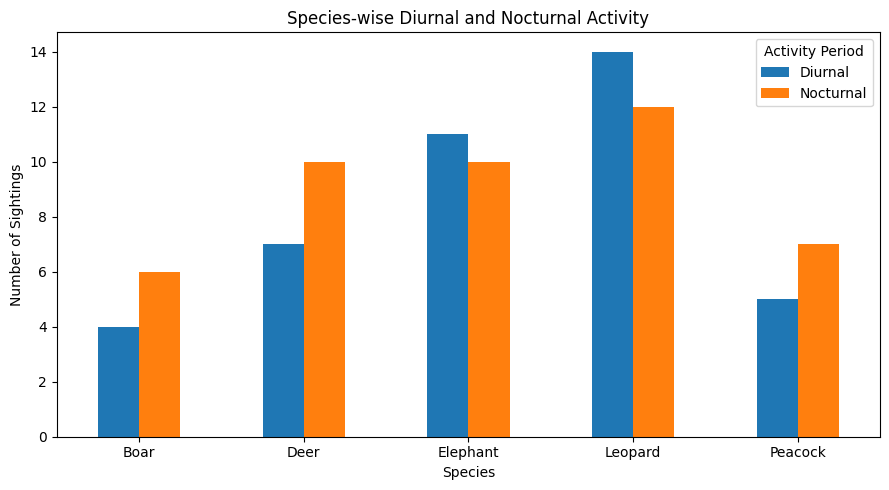

In [26]:
species_period = pd.crosstab(
    df["species"],
    df["activity_period"]
)

species_period.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Species-wise Diurnal and Nocturnal Activity")
plt.xlabel("Species")
plt.ylabel("Number of Sightings")
plt.xticks(rotation=0)
plt.legend(title="Activity Period")
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

# Load the original dataset
df = pd.read_csv("Q08_wildlife_camera_trap.csv")

# 1. Remove missing values
df = df.dropna()

# 2. Remove duplicate records
df = df.drop_duplicates()

# 3. Remove blank trigger records
df = df[df["trigger_type"].str.strip().str.lower() != "blank"]

# 4. Convert sighting time to datetime
df["sighting_time"] = pd.to_datetime(
    df["sighting_time"],
    errors="coerce"
)

# Remove invalid time values
df = df.dropna(subset=["sighting_time"])

# 5. Extract hour from sighting time
df["hour"] = df["sighting_time"].dt.hour

# 6. Create Diurnal / Nocturnal feature
df["activity_period"] = df["hour"].apply(
    lambda x: "Nocturnal"
    if x >= 18 or x < 6
    else "Diurnal"
)

# 7. Save cleaned dataset as Excel
df.to_excel(
    "cleaned_wildlife_camera_trap.xlsx",
    index=False
)

print("Cleaning completed successfully!")
print("Excel file saved as: cleaned_wildlife_camera_trap.xlsx")
print("Number of records:", len(df))

Cleaning completed successfully!
Excel file saved as: cleaned_wildlife_camera_trap.xlsx
Number of records: 86
